$\Huge{\text{Germán Cousillas Martínez}}$

# Ejercicio 1

In [3]:
# Definimos constantes del problema
Om_m = 0.315
Om_l = 0.6847
Om_r = 9.4e-5
Om_k = 1-Om_m-Om_l-Om_r
H0 = 0.069 # Gaños^-1

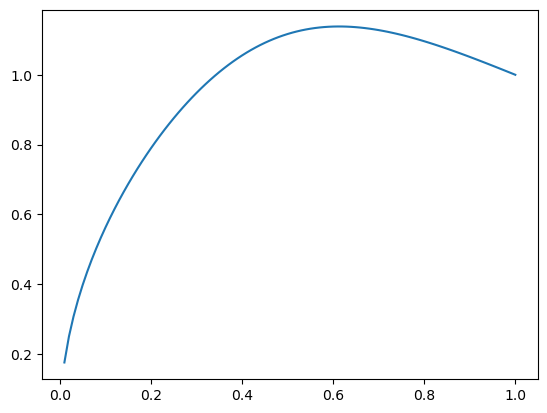

In [4]:
# Representamos integrando del factor de escala
import numpy as np
import matplotlib.pyplot as plt

f = lambda a: 1/a/np.sqrt(Om_r/a**4 + Om_m/a**3+Om_k/a**2+Om_l)

a = np.linspace(0.01,1,100)
plt.plot(a, f(a))
plt.show()

$$t_0=\frac{1}{H_0}\int_0^1\frac{da}{a\sqrt{\Omega_{r,0}\left(\frac{a_0}{a}\right)^4+\Omega_{m,0}\left(\frac{a_0}{a}\right)^3+\Omega_{\kappa,0}\left(\frac{a_0}{a}\right)^2+\Omega_{\Lambda,0}}}$$

In [5]:
# Procedemos por cuadratura Gaussiana porque la curva parece suficientemente suave como para poder aplicar
# este método
from gaussxw import gaussxwab

N=100
a, w = gaussxwab(N, 0, 1)

t0 = 1/H0*np.sum(w*f(a))
print(t0) # Giga-años

13.775870759408175


# Ejercicio 2

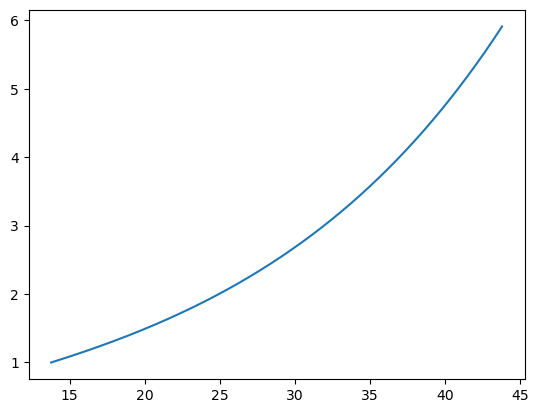

In [7]:
# Estudiamos evolución temporal del factor de escala del Universo: a(t)

# Procedemos por RK4

t_max=30+t0 # Gaños
N=1000
h=(t_max-t0)/N
tp = np.linspace(t0,t_max, N)

def F(r):
    a, v = r
    return np.array([v, -H0**2/2*Om_m * (2*Om_r*a**(-4)+Om_m*a**(-3)-2*Om_l)/( v**2/H0**2-Om_r*a**(-2)-Om_l*a**2-Om_k )], float)


r = np.array([1, H0]) # conds. iniciales: a(t0)=1; da/dt = H0
ap = []
vp=[]

for t in tp:
    ap.append(r[0])
    vp.append(r[1])
    k1 = h*F(r)
    k2 = h*F(r+k1/2)
    k3 = h*F(r+k2/2)
    k4 = h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(tp, ap)
plt.show()

**Vemos que la expansión del Universo es acelerada porque la curva es convexa --> aceleración positiva**

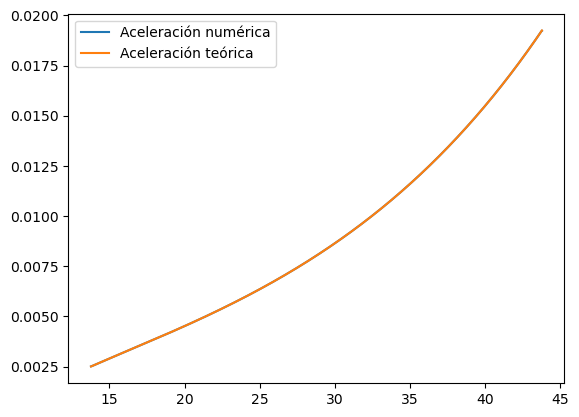

In [14]:
ap = np.array(ap)
vp = np.array(vp)

acel_teo = lambda a, v: -H0**2/2*Om_m * (2*Om_r*a**(-4)+Om_m*a**(-3)-2*Om_l)/( v**2/H0**2-Om_r*a**(-2)-Om_l*a**2-Om_k )
acel_num = np.empty_like(vp)
acel_num[0] = (vp[1]-vp[0])/h
acel_num[N-1] = (vp[N-1]-vp[N-2])/h
acel_num[1:N-1] = (vp[2:N]-vp[0:N-2])/(2*h)

plt.plot(tp, acel_num, label="Aceleración numérica")
plt.plot(tp, acel_teo(ap, vp), label="Aceleración teórica")
plt.legend()
plt.show()

**Donde mas deben diferir es en los extremos, pues se han empleado diferencias adelantadas / atrasadas en oposición a las centradas, que son más precisas**

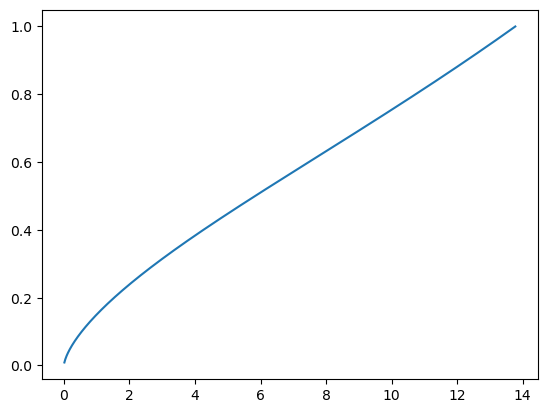

In [7]:
# Estudiamos evolución temporal del factor de escala del Universo hasta su origen

# Procedemos por RK4
import numpy as np
import matplotlib.pyplot as plt

N=1000
h=(t0)/N

def F(r):
    a, v = r
    return np.array([v, -H0**2/2*Om_m * (2*Om_r*a**(-4)+Om_m*a**(-3)-2*Om_l)/( v**2/H0**2-Om_r*a**(-2)-Om_l*a**2-Om_k )], float)


r = np.array([1, H0]) # conds. iniciales: a(t0)=1; da/dt = H0
ap = []
vp=[]

t=t0
tp = []

while t > 0:
    ap.append(r[0])
    vp.append(r[1])
    tp.append(t)
    
    k1 = -h*F(r)
    k2 = -h*F(r+k1/2)
    k3 = -h*F(r+k2/2)
    k4 = -h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)
    
    t-= h
    
plt.plot(tp, ap)
plt.show()

# Ejercicio 3: futuros del Universo

## Apartado 1: Sin constante cosmológica

In [8]:
# Definimos constantes del problema
Om_m = 0.315
Om_l = 0
Om_r = 9.4e-5
Om_k = 1-Om_m-Om_l-Om_r
H0 = 0.069 # Gaños^-1

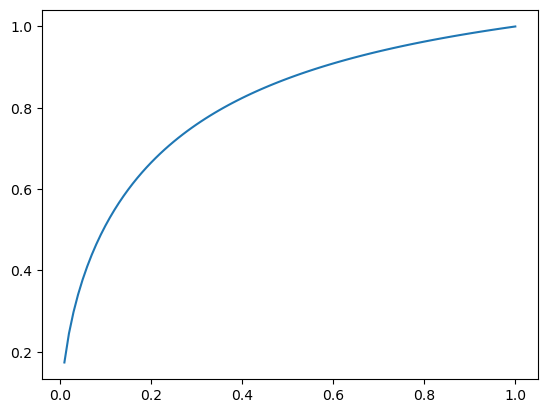

In [9]:
# Representamos integrando del factor de escala
import numpy as np
import matplotlib.pyplot as plt

f = lambda a: 1/a/np.sqrt(Om_r/a**4 + Om_m/a**3+Om_k/a**2+Om_l)

a = np.linspace(0.01,1,100)
plt.plot(a, f(a))
plt.show()

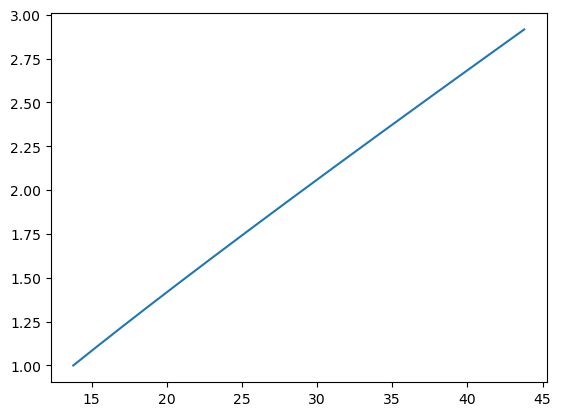

In [10]:
# Estudiamos evolución temporal del factor de escala del Universo: a(t)

# Procedemos por RK4


t0 = 13.775870759408175 # Es importante notar que esta es la edad que sabemos que tiene pero el modelo daría otra
t_max=30+t0 # Gaños
N=1000
h=(t_max-t0)/N
tp = np.linspace(t0,t_max, N)

def F(r):
    a, v = r
    return np.array([v, -H0**2/2*Om_m * (2*Om_r*a**(-4)+Om_m*a**(-3)-2*Om_l)/( v**2/H0**2-Om_r*a**(-2)-Om_l*a**2-Om_k )], float)


r = np.array([1, H0]) # conds. iniciales: a(t0)=1; da/dt = H0
ap = []
vp=[]

for t in tp:
    ap.append(r[0])
    vp.append(r[1])
    k1 = h*F(r)
    k2 = h*F(r+k1/2)
    k3 = h*F(r+k2/2)
    k4 = h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(tp, ap)
plt.show()

## Apartado 2: Universo de De Sitter

In [11]:
# Definimos constantes del problema
Om_m = 1
Om_l = 0
Om_r = 0
Om_k = 1-Om_m-Om_l-Om_r
H0 = 0.069 # Gaños^-1

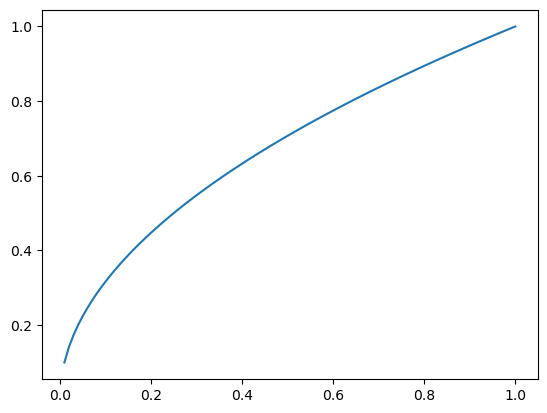

In [12]:
# Representamos integrando del factor de escala
import numpy as np
import matplotlib.pyplot as plt

f = lambda a: 1/a/np.sqrt(Om_r/a**4 + Om_m/a**3+Om_k/a**2+Om_l)

a = np.linspace(0.01,1,100)
plt.plot(a, f(a))
plt.show()

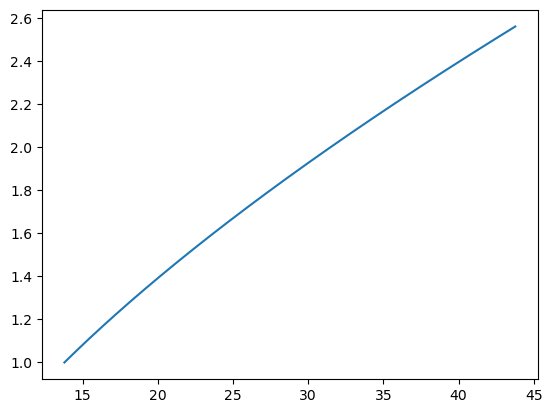

In [13]:
# Estudiamos evolución temporal del factor de escala del Universo: a(t)

# Procedemos por RK4


t0 = 13.775870759408175 # Es importante notar que esta es la edad que sabemos que tiene pero el modelo daría otra
t_max=30+t0 # Gaños
N=1000
h=(t_max-t0)/N
tp = np.linspace(t0,t_max, N)

def F(r):
    a, v = r
    return np.array([v, -H0**2/2*Om_m * (2*Om_r*a**(-4)+Om_m*a**(-3)-2*Om_l)/( v**2/H0**2-Om_r*a**(-2)-Om_l*a**2-Om_k )], float)


r = np.array([1, H0]) # conds. iniciales: a(t0)=1; da/dt = H0
ap = []
vp=[]

for t in tp:
    ap.append(r[0])
    vp.append(r[1])
    k1 = h*F(r)
    k2 = h*F(r+k1/2)
    k3 = h*F(r+k2/2)
    k4 = h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(tp, ap)
plt.show()

## Apartado 3: Universo esférico (big crunch)

In [1]:
# Definimos constantes del problema
Om_m = 5
Om_l = 0
Om_r = 0
Om_k = 1-Om_m-Om_l-Om_r
H0 = 0.069 # Gaños^-1

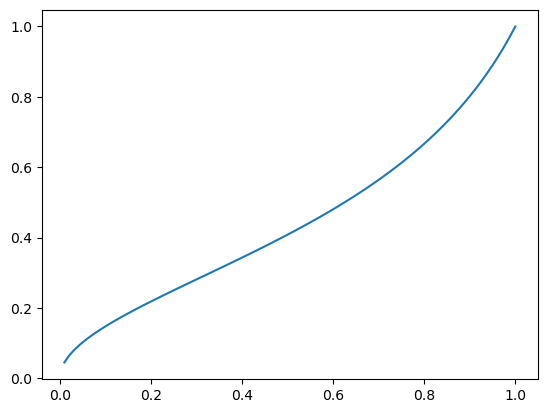

In [2]:
# Representamos integrando del factor de escala
import numpy as np
import matplotlib.pyplot as plt

f = lambda a: 1/a/np.sqrt(Om_r/a**4 + Om_m/a**3+Om_k/a**2+Om_l)

a = np.linspace(0.01,1,100)
plt.plot(a, f(a))
plt.show()

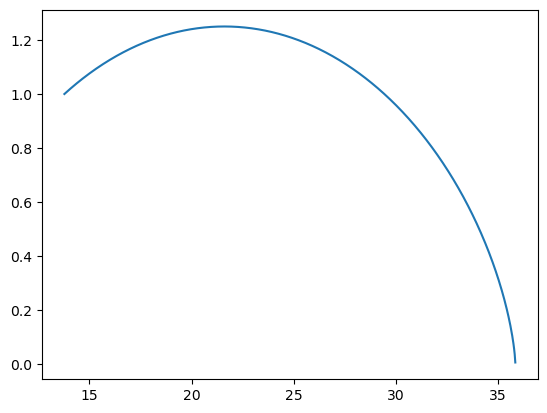

In [3]:
# Estudiamos evolución temporal del factor de escala del Universo: a(t)

# Procedemos por RK4


t0 = 13.775870759408175 # Es importante notar que esta es la edad que sabemos que tiene pero el modelo daría otra
t_max=30+t0 # Gaños
N=1000
h=(t_max-t0)/N
tp = np.linspace(t0,t_max, N)

def F(r):
    a, v = r
    return np.array([v, -H0**2/2*Om_m * (2*Om_r*a**(-4)+Om_m*a**(-3)-2*Om_l)/( v**2/H0**2-Om_r*a**(-2)-Om_l*a**2-Om_k )], float)


r = np.array([1, H0]) # conds. iniciales: a(t0)=1; da/dt = H0
ap = []
vp=[]

for t in tp:
    if r[0] <=0:
        break
    ap.append(r[0])
    vp.append(r[1])
    k1 = h*F(r)
    k2 = h*F(r+k1/2)
    k3 = h*F(r+k2/2)
    k4 = h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(tp[:len(ap)], ap)
plt.show()

## Apartado 4: Calcular $\Omega_{m,0}$ para que el Universo se contraiga a los 30 Gaños

In [4]:
# Definimos constantes del problema
Om_m = 5
Om_l = 0
Om_r = 0
Om_k = 1-Om_m-Om_l-Om_r
H0 = 0.069# Gaños^-1

In [5]:
def secante(f, der, x0, tol):
    err = 2*tol
    while err > tol:
        x1 = x0-f(x0)/der(x0)
        err = np.abs(x1-x0)
        x0=x1
    
    return x1

In [6]:
# Es un problema de condiciones de contorno que se puede resolver por el método del disparo

N=1000
t = np.linspace(t0,30,N)
h = (30-t0)/N

def a_30(Om_m):
    r = np.array([1,H0]) # Partimos del presente y queremos que el Universo se acabe de contraer en t=30Gaños
    # Resolvemos hasta 30Gaños y vemos qué a tenemos para un Om_m dado
    def F(r):
        a, v = r
        return np.array([v, -H0**2/2*Om_m * (2*Om_r*a**(-4)+Om_m*a**(-3)-2*Om_l)/( v**2/H0**2-Om_r*a**(-2)-Om_l*a**2-Om_k )], float)
    
    for t in tp:
        k1 = h*F(r)
        k2 = h*F(r+k1/2)
        k3 = h*F(r+k2/2)
        k4 = h*F(r+k3)
        
        r+=1/6*(k1+2*k2+2*k3+k4)
        
    return r[0] # a(30)

der = lambda Om_m: (a_30(Om_m+h)-a_30(Om_m-h))/(2*h)

Om_a = 5
Om_b = 6

Om_m = secante(a_30, der, 5.8,1e-6)
print(a_30(Om_m))

-1.660000401510717


In [10]:
# Comprobamos, resolviendo para esta Omega_m

# Definimos constantes del problema

Om_l = 0
Om_r = 0
Om_k = 1-Om_m-Om_l-Om_r
H0 = 0.069 # Gaños^-1

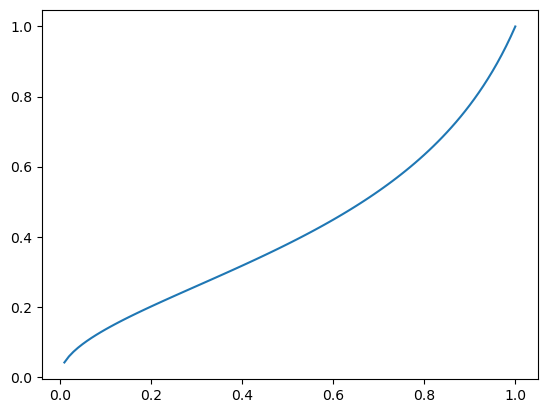

In [11]:
# Representamos integrando del factor de escala
import numpy as np
import matplotlib.pyplot as plt

f = lambda a: 1/a/np.sqrt(Om_r/a**4 + Om_m/a**3+Om_k/a**2+Om_l)

a = np.linspace(0.01,1,100)
plt.plot(a, f(a))
plt.show()

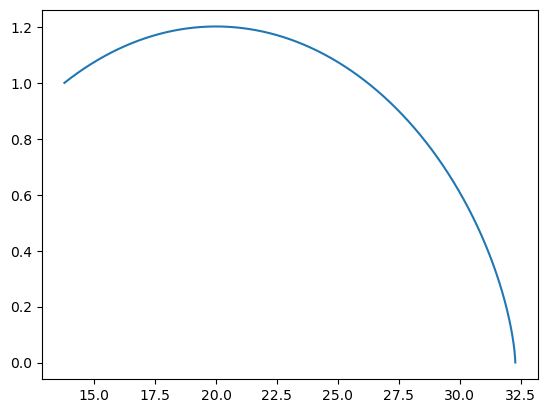

In [12]:
def F(r):
    a, v = r
    return np.array([v, -H0**2/2*Om_m * (2*Om_r*a**(-4)+Om_m*a**(-3)-2*Om_l)/( v**2/H0**2-Om_r*a**(-2)-Om_l*a**2-Om_k )], float)


r = np.array([1, H0]) # conds. iniciales: a(t0)=1; da/dt = H0
t=t0
ap = []
tp=[]

h = 1e-4

while r[0] >= 0:
    ap.append(r[0])
    tp.append(t)
    
    k1 = h*F(r)
    k2 = h*F(r+k1/2)
    k3 = h*F(r+k2/2)
    k4 = h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)
    t+=h
    
plt.plot(tp, ap)
plt.show()